In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

os.chdir('../..')

from src.geoadmin import load_neighborhoods, load_laraic


SYMDIFF_PATH = 'data/04_results/lariac_symdiff.gpkg'
MASTER_PATH  = 'data/processed/assessor_lariac.gpkg'
UDU_PATH     = 'data/01_raw/UDU Report 02_10_2026.csv'

CENSUS_TRACTS_PATH = 'data/03_processed/assessor_udu_tracts.gpkg'

def normalize_ain(s):
    return str(s).strip().replace('-', '')

In [2]:
udu_raw  = pd.read_csv(UDU_PATH)
udu_ains = set(
    udu_raw[udu_raw['assessor_parcel_number'] != '2654021BRK']
    ['assessor_parcel_number']
    .apply(normalize_ain)
    .unique()
)
print(f'{len(udu_ains):,} UDU AINs loaded')

442 UDU AINs loaded


In [3]:
# identify SFR AINs from master (2017 layer)
master = gpd.read_file(MASTER_PATH, layer='2017',
                       columns=['AIN', 'usetype'], read_geometry=False)
master['AIN'] = master['AIN'].apply(normalize_ain)

sfr_mask = master['usetype'].str.contains('Single', case=False, na=False)
sfr_ains = set(master.loc[sfr_mask & ~master['AIN'].isin(udu_ains), 'AIN'])
print(f"{len(sfr_ains):,} non-UDU SFR AINs available")

# build LA city neighborhood list
from src.geoadmin import load_cities
from tqdm.auto import tqdm

cities    = load_cities().to_crs(4326)
hoods     = load_neighborhoods()
lacity    = cities.query('CITYNAME_ALF == "LOS ANGELES"')
hoodnames = gpd.sjoin(
    hoods.set_geometry(hoods.centroid.to_crs(4326)).set_crs(4326),
    lacity[['geometry']],
    predicate='intersects'
)['name'].tolist()
lacity_hoods  = hoods[hoods['name'].isin(hoodnames)]
neighborhoods = list(lacity_hoods['name'])
print(f"Found {len(neighborhoods)} neighborhoods in LA city")

# loop through all neighborhoods, filtering each symdiff layer
results = []
for hood in tqdm(neighborhoods, desc='neighborhoods'):
    hood_safe = hood.replace("'", "''"  )   # escape single quotes for SQL
    for layer in ['symdiff_2014_2017', 'symdiff_2017_2020']:
        chunk = gpd.read_file(
            SYMDIFF_PATH, layer=layer,
            where=f"neighborhood = '{hood_safe}'"
        )
        chunk['AIN'] = chunk['AIN'].apply(normalize_ain)
        chunk = chunk[chunk['AIN'].isin(sfr_ains)]
        if len(chunk):
            results.append(chunk)

symdiff_sfr           = pd.concat(results, ignore_index=True)
symdiff_sfr['group']  = 'SFR (non-UDU)'
symdiff_sfr['is_udu'] = symdiff_sfr['AIN'].isin(udu_ains)

print(f"SFR: {symdiff_sfr['AIN'].nunique():,} AINs  |  {len(symdiff_sfr):,} rows")
symdiff_sfr.groupby(['epoch', 'change_type']).size().unstack(fill_value=0)

1,121,719 non-UDU SFR AINs available
Found 122 neighborhoods in LA city


/var/folders/7b/rl6lkdns1dbfv_n3wwwmq8580000gn/T/ipykernel_4982/2615250347.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hoods.set_geometry(hoods.centroid.to_crs(4326)).set_crs(4326),


neighborhoods:   0%|          | 0/122 [00:00<?, ?it/s]

SFR: 351,232 AINs  |  574,215 rows


change_type,added_structure,demolished,extended,new_parcel,no_change,reduced,removed_structure
epoch,,,,,,,
2014→2017,6247,24879,13764,4111,230693,7812,5628
2017→2020,3475,1020,13312,1441,246936,8891,6006


In [4]:
# ── Census tract control: SFR parcels in UDU-containing mixed-residential tracts ──
ct_parcels = gpd.read_file(
    CENSUS_TRACTS_PATH, layer='parcels',
    columns=['AIN', 'res_category', 'is_udu'],
    read_geometry=False,
)
ct_parcels['AIN'] = ct_parcels['AIN'].apply(normalize_ain)

ct_sfr_ains = set(
    ct_parcels.loc[
        (ct_parcels['res_category'] == 'sfr') & (~ct_parcels['is_udu']),
        'AIN'
    ]
)
print(f"{len(ct_sfr_ains):,} census-tract-restricted non-UDU SFR AINs")

# load symdiff for CT SFR directly from GPKG (SQL filter — no neighborhood loop needed)
ain_sql_ct = "','".join(sorted(ct_sfr_ains))
symdiff_sfr_ct = pd.concat([
    gpd.read_file(SYMDIFF_PATH, layer=layer, where=f"AIN IN ('{ain_sql_ct}')")
    for layer in ['symdiff_2014_2017', 'symdiff_2017_2020']
], ignore_index=True)
symdiff_sfr_ct['AIN']   = symdiff_sfr_ct['AIN'].apply(normalize_ain)
symdiff_sfr_ct['group'] = 'ct_sfr'

print(f"CT SFR symdiff: {symdiff_sfr_ct['AIN'].nunique():,} AINs  |  {len(symdiff_sfr_ct):,} rows")
symdiff_sfr_ct.groupby(['epoch', 'change_type']).size().unstack(fill_value=0)


94,611 census-tract-restricted non-UDU SFR AINs
CT SFR symdiff: 74,947 AINs  |  136,592 rows


change_type,added_structure,demolished,extended,new_parcel,no_change,reduced,removed_structure
epoch,,,,,,,
2014→2017,1490,493,3278,997,55179,1519,1415
2017→2020,894,276,3593,312,63136,2407,1603


In [5]:
from src.geoadmin import load_parcels_by_AIN

# assign each AIN one change_label — most structurally significant across both epochs
CHANGE_PRIORITY = {
    'added_structure': 0, 'removed_structure': 1,
    'extended': 2, 'reduced': 3,
    'new_parcel': 4, 'demolished': 5,
    'no_change': 6,
}
ain_change_label = (
    symdiff_sfr.groupby('AIN')['change_type']
    .apply(lambda s: min(s, key=lambda x: CHANGE_PRIORITY.get(x, 99)))
    .rename('change_label')
    .reset_index()
)
print(ain_change_label['change_label'].value_counts().to_string())


# census tract control group change labels
ct_ain_change_label = (
    symdiff_sfr_ct.groupby('AIN')['change_type']
    .apply(lambda s: min(s, key=lambda x: CHANGE_PRIORITY.get(x, 99)))
    .rename('change_label')
    .reset_index()
)
# load assessor roll history for all SFR non-UDU AINs in the symdiff sample
assr = (
    load_parcels_by_AIN(ain_change_label['AIN'].tolist())
    .dropna(subset=['SQFTmain', 'RollYear'])
    .sort_values(['AIN', 'RollYear'])
)
assr['AIN']     = assr['AIN'].apply(normalize_ain)
assr['SQFTmain'] = pd.to_numeric(assr['SQFTmain'], errors='coerce')
assr = assr.merge(ain_change_label, on='AIN', how='left')

print(f"Assessor rows: {len(assr):,}  |  unique AINs: {assr['AIN'].nunique():,}")
assr[['AIN', 'RollYear', 'SQFTmain', 'change_label']].head()

change_label
no_change            261837
extended              25166
demolished            23576
reduced               14992
removed_structure     10924
added_structure        9620
new_parcel             5117
Assessor rows: 6,636,017  |  unique AINs: 351,232


,AIN,RollYear,SQFTmain,change_label
0,2004001003,2006,2090,no_change
1,2004001003,2007,2090,no_change
2,2004001003,2008,2090,no_change
3,2004001003,2009,2090,no_change
4,2004001003,2010,2090,no_change


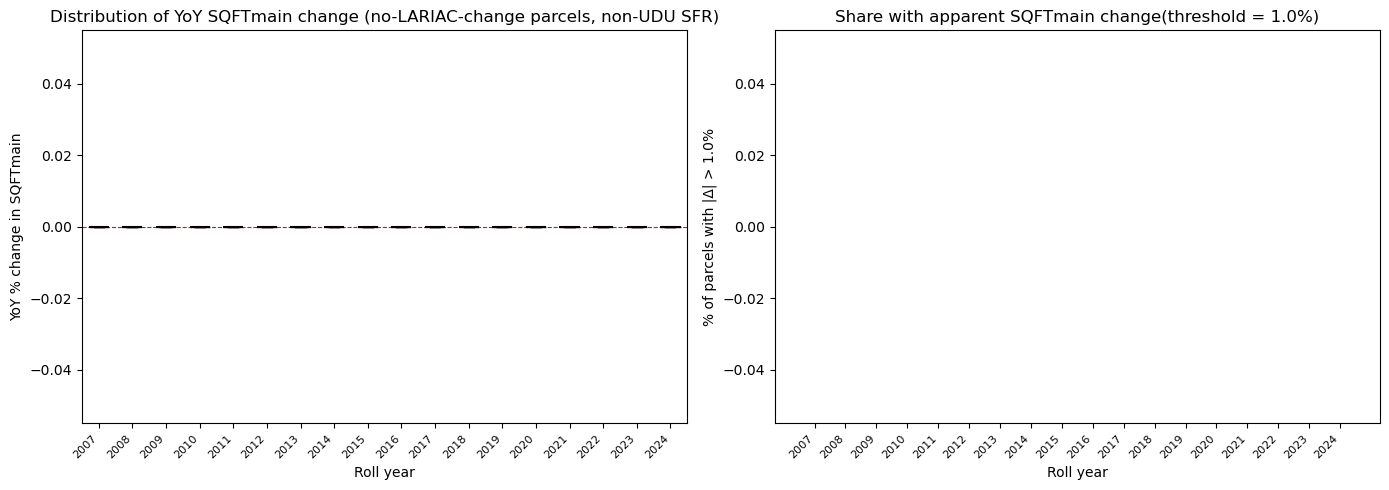

Median absolute change per year:
RollYear
2007    0.0
2008    0.0
2009    0.0
2010    0.0
2011    0.0
2012    0.0
2013    0.0
2014    0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
2022    0.0
2023    0.0
2024    0.0


In [6]:
# year-over-year pct change in SQFTmain per parcel
assr_sorted = assr.sort_values(['AIN', 'RollYear'])
assr_sorted['sqft_pct_chg'] = (
    assr_sorted.groupby('AIN')['SQFTmain']
    .pct_change() * 100
)

# drop the first observation per parcel (no previous year to diff against)
chg = assr_sorted.dropna(subset=['sqft_pct_chg']).copy()

# winsorise extreme tails for cleaner visualisation
lo, hi = chg['sqft_pct_chg'].quantile([0.01, 0.99])
chg_w = chg[chg['sqft_pct_chg'].between(lo, hi)]

years = sorted(chg_w['RollYear'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: boxplot per year ---
ax = axes[0]
data_by_year = [chg_w.loc[chg_w['RollYear'] == y, 'sqft_pct_chg'].values for y in years]
bp = ax.boxplot(data_by_year, positions=years, widths=0.6,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='black', lw=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0')
    patch.set_alpha(0.6)
ax.axhline(0, color='red', lw=0.8, ls='--')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Roll year')
ax.set_ylabel('YoY % change in SQFTmain')
ax.set_title('Distribution of YoY SQFTmain change (no-LARIAC-change parcels, non-UDU SFR)')

# --- right: share of parcels with any change (|pct_chg| > threshold) ---
ax2 = axes[1]
threshold = 1.0   # > 1 % counts as a "real" change
share = (
    chg_w.groupby('RollYear')
    .apply(lambda g: (g['sqft_pct_chg'].abs() > threshold).mean() * 100)
    .reset_index(name='pct_with_change')
)
ax2.bar(share['RollYear'], share['pct_with_change'], color='#C44E52', alpha=0.7)
ax2.set_xticks(share['RollYear'])
ax2.set_xticklabels(share['RollYear'], rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Roll year')
ax2.set_ylabel(f'% of parcels with |Δ| > {threshold}%')
ax2.set_title(f'Share with apparent SQFTmain change(threshold = {threshold}%)')

plt.tight_layout()
plt.show()

print(f"Median absolute change per year:")
print(chg_w.groupby('RollYear')['sqft_pct_chg'].apply(lambda x: x.abs().median()).round(3).to_string())

In [7]:
# ── combined long-format table: AIN × RollYear × Source × change_label × SQFT ──
M2_TO_SQFT = 10.7639

all_ain_set = set(ain_change_label['AIN'])

sd_early = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2014_2017')
sd_early['AIN'] = sd_early['AIN'].apply(normalize_ain)
sd_early = sd_early[sd_early['AIN'].isin(all_ain_set)]

sd_late = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2017_2020')
sd_late['AIN'] = sd_late['AIN'].apply(normalize_ain)
sd_late = sd_late[sd_late['AIN'].isin(all_ain_set)]

# LARIAC long — three epochs, join change_label
lar_parts = [
    sd_early[['AIN', 'area_2014']].rename(columns={'area_2014': 'SQFT'}).assign(RollYear=2014),
    sd_early[['AIN', 'area_2017']].rename(columns={'area_2017': 'SQFT'}).assign(RollYear=2017),
    sd_late [['AIN', 'area_2020']].rename(columns={'area_2020': 'SQFT'}).assign(RollYear=2020),
]
lar_long = (
    pd.concat(lar_parts, ignore_index=True)
    .assign(SQFT=lambda d: d['SQFT'] * M2_TO_SQFT, Source='lariac', group='all_sfr')
    .merge(ain_change_label, on='AIN', how='left')
)

# assessor long — already has change_label from cell 3 merge
assr_long = (
    assr[['AIN', 'RollYear', 'SQFTmain', 'change_label']]
    .rename(columns={'SQFTmain': 'SQFT'})
    .assign(Source='assessor', group='all_sfr')
)


# ── CT control: assessor and LARIAC for census-tract-restricted SFR ───────────
ct_all_ain = set(ct_ain_change_label['AIN'])

sd_early_ct = sd_early[sd_early['AIN'].isin(ct_all_ain)]
sd_late_ct  = sd_late [sd_late ['AIN'].isin(ct_all_ain)]

ct_lar_parts = [
    sd_early_ct[['AIN', 'area_2014']].rename(columns={'area_2014': 'SQFT'}).assign(RollYear=2014),
    sd_early_ct[['AIN', 'area_2017']].rename(columns={'area_2017': 'SQFT'}).assign(RollYear=2017),
    sd_late_ct [['AIN', 'area_2020']].rename(columns={'area_2020': 'SQFT'}).assign(RollYear=2020),
]
ct_lar_long = (
    pd.concat(ct_lar_parts, ignore_index=True)
    .assign(SQFT=lambda d: d['SQFT'] * M2_TO_SQFT, Source='lariac', group='ct_sfr')
    .merge(ct_ain_change_label, on='AIN', how='left')
)

ct_assr_long = (
    assr[assr['AIN'].isin(ct_all_ain)][['AIN', 'RollYear', 'SQFTmain', 'change_label']]
    .rename(columns={'SQFTmain': 'SQFT'})
    .assign(Source='assessor', group='ct_sfr')
)
sqft_long = pd.concat([assr_long, lar_long, ct_assr_long, ct_lar_long], ignore_index=True)
sqft_long['SQFT'] = pd.to_numeric(sqft_long['SQFT'], errors='coerce')
sqft_long = sqft_long.dropna(subset=['SQFT']).query('SQFT > 0')

print(f"Rows: {len(sqft_long):,}  |  AINs: {sqft_long['AIN'].nunique():,}")
sqft_long.groupby(['Source', 'change_label']).size().unstack(fill_value=0)

Rows: 8,966,381  |  AINs: 351,195


change_label,added_structure,demolished,extended,new_parcel,no_change,reduced,removed_structure
Source,,,,,,,
assessor,222958,437157,592057,73352,6000503,347796,256022
lariac,33273,27073,86153,11242,792734,48909,37152


In [8]:
# variability summary per (AIN, Source, change_label)
variability = (
    sqft_long
    .groupby(['AIN', 'Source', 'change_label', 'group'])['SQFT']
    .agg(n='count', mean='mean', std='std', min='min', max='max')
    .assign(cv=lambda d: d['std'] / d['mean'],
            range_pct=lambda d: (d['max'] - d['min']) / d['mean'] * 100)
    .round(3)
    .reset_index()
)

print(variability.groupby(['Source', 'change_label'])[['cv', 'range_pct']].median().round(3).to_string())
variability.head(10)

                               cv  range_pct
Source   change_label                       
assessor added_structure    0.000      0.000
         demolished         0.000      0.000
         extended           0.000      0.000
         new_parcel         0.000      0.000
         no_change          0.000      0.000
         reduced            0.000      0.000
         removed_structure  0.000      0.000
lariac   added_structure    0.124     20.024
         demolished         0.000      0.000
         extended           0.069     10.508
         new_parcel         0.000      0.000
         no_change          0.000      0.000
         reduced            0.050      7.439
         removed_structure  0.045      6.429


,AIN,Source,change_label,group,n,mean,std,min,max,cv,range_pct
0,2004001003,assessor,no_change,all_sfr,19,2090.000,0.000,2090.000,2090.000,0.000,0.000
1,2004001003,lariac,no_change,all_sfr,2,3008.099,0.006,3008.095,3008.103,0.000,0.000
2,2004001004,assessor,no_change,all_sfr,19,2479.000,0.000,2479.000,2479.000,0.000,0.000
3,2004001004,lariac,no_change,all_sfr,2,2690.543,0.001,2690.543,2690.544,0.000,0.000
4,2004001005,assessor,no_change,all_sfr,19,2057.000,0.000,2057.000,2057.000,0.000,0.000
5,2004001005,lariac,no_change,all_sfr,2,3613.952,0.006,3613.947,3613.956,0.000,0.000
6,2004001008,assessor,no_change,all_sfr,19,2423.000,0.000,2423.000,2423.000,0.000,0.000
7,2004001008,lariac,no_change,all_sfr,2,3167.661,0.003,3167.659,3167.664,0.000,0.000
8,2004001009,assessor,removed_structure,all_sfr,19,2226.000,0.000,2226.000,2226.000,0.000,0.000
9,2004001009,lariac,removed_structure,all_sfr,2,3122.496,161.549,3008.264,3236.728,0.052,7.317


In [9]:
variability.groupby('Source').max()

,AIN,change_label,group,n,mean,std,min,max,cv,range_pct
Source,,,,,,,,,,
assessor,7588022020,removed_structure,ct_sfr,19,482248.000,126291.718,482248.000,538370.000,3.903,1661.456
lariac,7588022020,removed_structure,ct_sfr,45,351557.361,136330.951,351557.361,351557.361,3.196,1990.604


Saved → notebooks/tasks/figures/sfr_sqft_variability_by_change_type.png


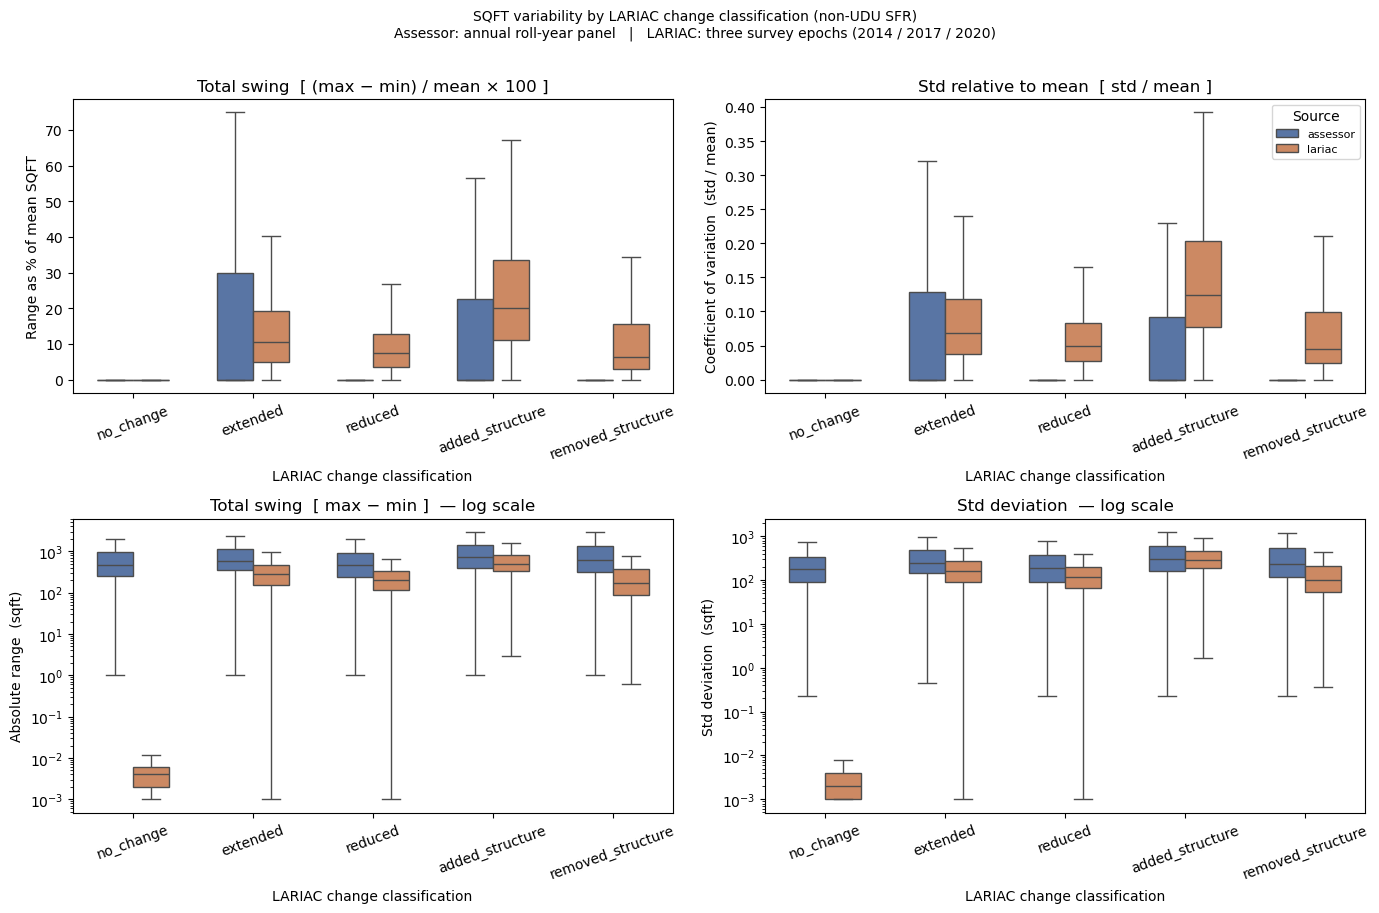

In [10]:
import seaborn as sns

variability['range_abs'] = variability['max'] - variability['min']

CHANGE_ORDER = ['no_change', 'extended', 'reduced', 'added_structure', 'removed_structure']
change_order = [c for c in CHANGE_ORDER if c in variability['change_label'].unique()]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_spec = [
    (axes[0, 0], 'range_pct', 'Range as % of mean SQFT',               'Total swing  [ (max − min) / mean × 100 ]', False),
    (axes[0, 1], 'cv',        'Coefficient of variation  (std / mean)', 'Std relative to mean  [ std / mean ]',      False),
    (axes[1, 0], 'range_abs', 'Absolute range  (sqft)',                 'Total swing  [ max − min ]  — log scale',   True),
    (axes[1, 1], 'std',       'Std deviation  (sqft)',                  'Std deviation  — log scale',                True),
]

for ax, col, ylabel, title, log_scale in plot_spec:
    plot_data = variability.copy()
    if log_scale:
        plot_data = plot_data[plot_data[col] > 0]
    sns.boxplot(
        data=plot_data, x='change_label', y=col,
        hue='Source', order=change_order, hue_order=['assessor', 'lariac'],
        palette={'assessor': '#4C72B0', 'lariac': '#DD8452'},
        showfliers=False, width=0.6, ax=ax,
    )
    if log_scale:
        ax.set_yscale('log')
    ax.set_xlabel('LARIAC change classification', labelpad=6)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.get_legend().remove()

axes[0, 1].legend(title='Source', fontsize=8, loc='upper right')

fig.suptitle(
    'SQFT variability by LARIAC change classification (non-UDU SFR)\n'
    'Assessor: annual roll-year panel   |   LARIAC: three survey epochs (2014 / 2017 / 2020)',
    fontsize=10, y=1.01
)
plt.tight_layout()

FIG_PATH = "notebooks/tasks/figures/sfr_sqft_variability_by_change_type.png"
plt.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
print(f"Saved → {FIG_PATH}")
plt.show()

Saved → notebooks/tasks/figures/sfr_ct_control_variability.png


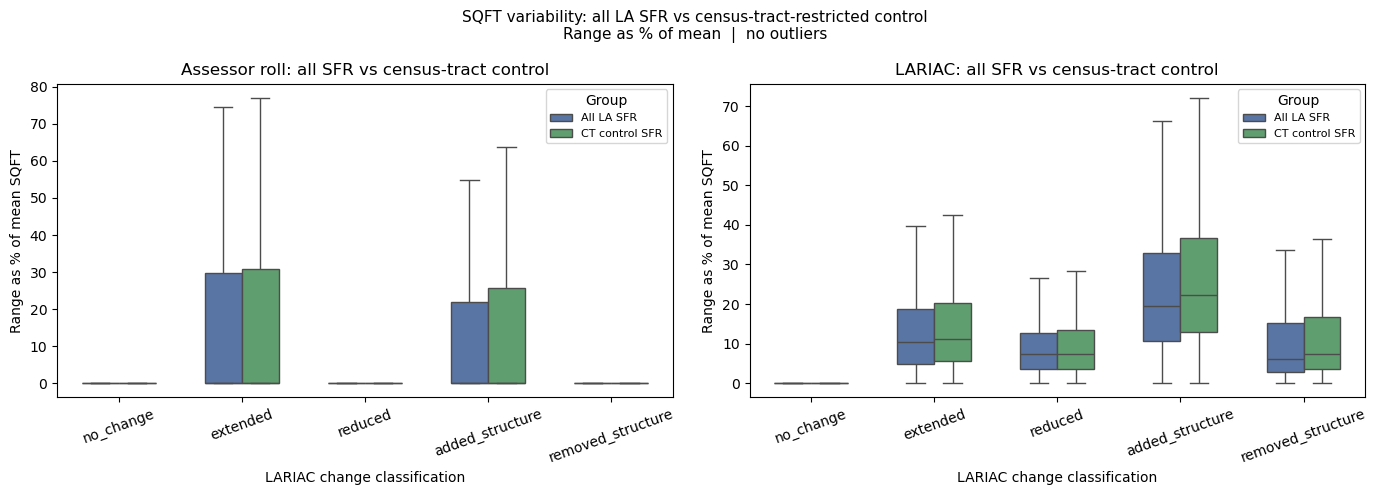

In [11]:
# ── Census tract control vs all-SFR: variability comparison ──────────────────
variability['range_abs'] = variability['max'] - variability['min']

CHANGE_ORDER = ['no_change', 'extended', 'reduced', 'added_structure', 'removed_structure']
change_order = [c for c in CHANGE_ORDER if c in variability['change_label'].unique()]

GROUP_COLORS = {'all_sfr': '#4C72B0', 'ct_sfr': '#55A868'}
GROUP_LABELS = {'all_sfr': 'All LA SFR', 'ct_sfr': 'CT control SFR'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (source, source_label) in zip(axes, [('assessor', 'Assessor roll'), ('lariac', 'LARIAC')]):
    plot_data = variability[variability['Source'] == source].copy()
    plot_data = plot_data[plot_data['range_pct'] >= 0]

    import seaborn as sns
    sns.boxplot(
        data=plot_data, x='change_label', y='range_pct',
        hue='group', order=change_order,
        hue_order=['all_sfr', 'ct_sfr'],
        palette=GROUP_COLORS,
        showfliers=False, width=0.6, ax=ax,
    )
    ax.set_xlabel('LARIAC change classification')
    ax.set_ylabel('Range as % of mean SQFT')
    ax.set_title(f'{source_label}: all SFR vs census-tract control')
    ax.tick_params(axis='x', rotation=20)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [GROUP_LABELS[l] for l in labels], fontsize=8, title='Group')

plt.suptitle(
    'SQFT variability: all LA SFR vs census-tract-restricted control\n'
    'Range as % of mean  |  no outliers',
    fontsize=11
)
plt.tight_layout()

OUT_FIG = 'notebooks/tasks/figures/sfr_ct_control_variability.png'
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)
plt.savefig(OUT_FIG, dpi=150, bbox_inches='tight')
print(f"Saved → {OUT_FIG}")
plt.show()


In [12]:
out = (
    variability[['AIN', 'change_label', 'Source', 'group', 'range_abs', 'range_pct']]
    .rename(columns={
        'change_label': 'Classification',
        'range_abs':    'AbsoluteRange',
        'range_pct':    'PctRange',
        'group':        'Group',
    })
)

OUT_PATH = 'data/03_processed/sfr_sqft_variability_by_change_type.csv'
out.to_csv(OUT_PATH, index=False)
print(f"Saved {len(out):,} rows → {OUT_PATH}")
out.head()

Saved 847,441 rows → data/03_processed/sfr_sqft_variability_by_change_type.csv


,AIN,Classification,Source,Group,AbsoluteRange,PctRange
0,2004001003,no_change,assessor,all_sfr,0.000,0.0
1,2004001003,no_change,lariac,all_sfr,0.008,0.0
2,2004001004,no_change,assessor,all_sfr,0.000,0.0
3,2004001004,no_change,lariac,all_sfr,0.001,0.0
4,2004001005,no_change,assessor,all_sfr,0.000,0.0


In [13]:
out

,AIN,Classification,Source,Group,AbsoluteRange,PctRange
0,2004001003,no_change,assessor,all_sfr,0.000,0.000
1,2004001003,no_change,lariac,all_sfr,0.008,0.000
2,2004001004,no_change,assessor,all_sfr,0.000,0.000
3,2004001004,no_change,lariac,all_sfr,0.001,0.000
4,2004001005,no_change,assessor,all_sfr,0.000,0.000
...,...,...,...,...,...,...
847436,7584003023,demolished,lariac,all_sfr,0.000,0.000
847437,7584019001,demolished,assessor,all_sfr,1344.000,53.867
847438,7584019001,demolished,lariac,all_sfr,272.455,10.813
847439,7588022020,demolished,assessor,all_sfr,1263.000,24.628
